In [ ]:
# ============================================================
# CELL 1: Setup Kaggle API
# ============================================================
import os

os.environ['KAGGLE_CONFIG_DIR'] = "/content"

with open('/content/kaggle.json', 'w') as f:
    f.write('{"username":"YOUR_KAGGLE_USERNAME","key":"9b6c73fb28a4338e391a0ac5d22ed596"}')

!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API configured")

✅ Kaggle API configured


In [ ]:
# ============================================================
# CELL 2: Download 3 datasets
# ============================================================
!mkdir -p /content/datasets

datasets = {
    "ravdess": "uwrfkaggler/ravdess-emotional-speech-audio",
    "tess": "ejlok1/toronto-emotional-speech-set-tess",
    "savee": "ejlok1/surrey-audiovisual-expressed-emotion-savee",
}

for name, slug in datasets.items():
    print(f"--- Downloading {name.upper()} ---")
    path = f"/content/datasets/{name}"
    !mkdir -p {path}
    !kaggle datasets download -d {slug} -p {path} --unzip

print("✅ All datasets downloaded")

--- Downloading RAVDESS ---
Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
 92% 393M/429M [00:00<00:00, 402MB/s]
100% 429M/429M [00:01<00:00, 432MB/s]
--- Downloading TESS ---
Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 96% 409M/428M [00:07<00:00, 67.6MB/s]
100% 428M/428M [00:07<00:00, 60.1MB/s]
--- Downloading SAVEE ---
Dataset URL: https://www.kaggle.com/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee
License(s): copyright-authors
 87% 94.0M/107M [00:00<00:00, 958MB/s]
100% 107M/107M [00:00<00:00, 681MB/s] 
✅ All datasets downloaded


In [ ]:
# ============================================================
# CELL 3: Install dependencies
# ============================================================
!pip install -q librosa soundfile

print("✅ Dependencies installed")

✅ Dependencies installed


In [ ]:
# ============================================================
# CELL 4: Parse all 3 datasets into unified DataFrame
# ============================================================
import os
import pandas as pd
import numpy as np

# --- Paths ---
RAVDESS_DIR = '/content/datasets/ravdess'
TESS_DIR = '/content/datasets/tess/TESS Toronto emotional speech set data'
SAVEE_DIR = '/content/datasets/savee'

print("=" * 60)
print("PARSING DATASETS")
print("=" * 60)

# --- RAVDESS ---
RAVDESS_EMO = {
    '01': 'neutral', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fear', '07': 'disgust', '08': 'surprise'
}

rows = []
for actor in sorted(os.listdir(RAVDESS_DIR)):
    apath = os.path.join(RAVDESS_DIR, actor)
    if not os.path.isdir(apath):
        continue
    for f in sorted(os.listdir(apath)):
        if not f.endswith('.wav'):
            continue
        parts = f[:-4].split('-')
        emo_code = parts[2]
        # Skip calm (02)
        if emo_code == '02':
            continue
        emo = RAVDESS_EMO.get(emo_code, 'unknown')
        if emo == 'unknown':
            continue
        # Gender: even actor number = Female, odd = Male
        actor_num = int(parts[6])
        gender = 'Female' if actor_num % 2 == 0 else 'Male'
        rows.append({
            'original_path': os.path.join(apath, f),
            'original_filename': f,
            'emotion': emo,
            'gender': gender,
            'speaker_id': f'RAVDESS_{actor}',
            'source': 'ravdess'
        })
df_rav = pd.DataFrame(rows)
print(f"RAVDESS : {len(df_rav)} files")

# --- TESS ---
TESS_EMO = {
    'angry': 'angry', 'disgust': 'disgust', 'fear': 'fear',
    'happy': 'happy', 'neutral': 'neutral', 'sad': 'sad',
    'pleasant_surprise': 'surprise', 'Pleasant_surprise': 'surprise',
    'pleasant_surprised': 'surprise', 'ps': 'surprise'
}

rows = []
for folder in sorted(os.listdir(TESS_DIR)):
    fpath = os.path.join(TESS_DIR, folder)
    if not os.path.isdir(fpath):
        continue
    parts = folder.split('_', 1)
    if len(parts) < 2:
        continue
    spk, ekey = parts[0], parts[1]
    emo = TESS_EMO.get(ekey, TESS_EMO.get(ekey.lower(), 'unknown'))
    if emo == 'unknown':
        continue
    for f in sorted(os.listdir(fpath)):
        if not f.endswith('.wav'):
            continue
        rows.append({
            'original_path': os.path.join(fpath, f),
            'original_filename': f,
            'emotion': emo,
            'gender': 'Female',  # TESS only has female speakers
            'speaker_id': f'TESS_{spk}',
            'source': 'tess'
        })
df_tess = pd.DataFrame(rows)
print(f"TESS    : {len(df_tess)} files")

# --- SAVEE ---
SAVEE_EMO = {
    'a': 'angry', 'd': 'disgust', 'f': 'fear', 'h': 'happy',
    'n': 'neutral', 'sa': 'sad', 'su': 'surprise'
}

rows = []
savee_all_dir = os.path.join(SAVEE_DIR, 'ALL')

# Fallback: nếu không có thư mục ALL, dùng SAVEE_DIR trực tiếp
if not os.path.isdir(savee_all_dir):
    savee_all_dir = SAVEE_DIR

for f in sorted(os.listdir(savee_all_dir)):
    if not f.endswith('.wav'):
        continue
    name_no_ext = f[:-4]
    parts = name_no_ext.split('_')
    if len(parts) < 2:
        continue

    # Speaker ID từ phần đầu: DC, JE, JK, KL
    spk = parts[0]

    # Emotion từ phần sau: a01 → 'a', sa01 → 'sa', su03 → 'su'
    epart = parts[1]
    emo = SAVEE_EMO.get(epart[:2], SAVEE_EMO.get(epart[:1], 'unknown'))
    if emo == 'unknown':
        continue

    rows.append({
        'original_path': os.path.join(savee_all_dir, f),
        'original_filename': f,
        'emotion': emo,
        'gender': 'Male',
        'speaker_id': f'SAVEE_{spk}',
        'source': 'savee'
    })

df_savee = pd.DataFrame(rows)
print(f"SAVEE   : {len(df_savee)} files")
print(f"  Speakers: {sorted(df_savee['speaker_id'].unique())}")
print(f"  Emotions: {sorted(df_savee['emotion'].unique())}")

# --- Combine ---
df = pd.concat([df_rav, df_tess, df_savee], ignore_index=True)

print(f"\n{'=' * 60}")
print(f"TOTAL   : {len(df)} files")
print(f"{'=' * 60}")
print(f"\nEmotion distribution:")
print(df['emotion'].value_counts().sort_index())
print(f"\nSpeaker distribution:")
print(df['speaker_id'].value_counts().sort_index())
print(f"\nSource distribution:")
print(df['source'].value_counts())
print(f"\nGender distribution:")
print(df['gender'].value_counts())

PARSING DATASETS
RAVDESS : 1248 files
TESS    : 2800 files
SAVEE   : 480 files
  Speakers: ['SAVEE_DC', 'SAVEE_JE', 'SAVEE_JK', 'SAVEE_KL']
  Emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

TOTAL   : 4528 files

Emotion distribution:
emotion
angry       652
disgust     652
fear        652
happy       652
neutral     616
sad         652
surprise    652
Name: count, dtype: int64

Speaker distribution:
speaker_id
RAVDESS_Actor_01      52
RAVDESS_Actor_02      52
RAVDESS_Actor_03      52
RAVDESS_Actor_04      52
RAVDESS_Actor_05      52
RAVDESS_Actor_06      52
RAVDESS_Actor_07      52
RAVDESS_Actor_08      52
RAVDESS_Actor_09      52
RAVDESS_Actor_10      52
RAVDESS_Actor_11      52
RAVDESS_Actor_12      52
RAVDESS_Actor_13      52
RAVDESS_Actor_14      52
RAVDESS_Actor_15      52
RAVDESS_Actor_16      52
RAVDESS_Actor_17      52
RAVDESS_Actor_18      52
RAVDESS_Actor_19      52
RAVDESS_Actor_20      52
RAVDESS_Actor_21      52
RAVDESS_Actor_22      52
RAVDE

In [ ]:
# ============================================================
# CELL 5: Remove duplicates by MD5 hash
# ============================================================
import hashlib

print("Calculating MD5 hashes...")

def compute_md5(filepath):
    h = hashlib.md5()
    with open(filepath, 'rb') as f:
        while chunk := f.read(8192):
            h.update(chunk)
    return h.hexdigest()

df['md5'] = df['original_path'].apply(compute_md5)

before_count = len(df)
df = df.drop_duplicates(subset='md5', keep='first').reset_index(drop=True)
after_count = len(df)

print(f"Before dedup: {before_count}")
print(f"After dedup : {after_count}")
print(f"Removed     : {before_count - after_count} duplicates")

# Drop md5 column, no longer needed
df = df.drop(columns=['md5'])

Calculating MD5 hashes...
Before dedup: 4528
After dedup : 4527
Removed     : 1 duplicates


In [ ]:
# ============================================================
# CELL 6: Train/Val/Test split (80/10/10) stratified by (speaker_id, emotion)
# ============================================================
np.random.seed(42)

splits = pd.Series('', index=df.index)

for (spk, emo), grp in df.groupby(['speaker_id', 'emotion']):
    idx = grp.index.tolist()
    np.random.shuffle(idx)
    n = len(idx)

    if n < 3:
        # Too few samples, put all in train
        splits.iloc[idx] = 'train'
        continue

    n_train = max(1, int(n * 0.80))
    n_val = max(1, int(n * 0.10))
    # Remaining goes to test
    splits.iloc[idx[:n_train]] = 'train'
    splits.iloc[idx[n_train:n_train + n_val]] = 'val'
    splits.iloc[idx[n_train + n_val:]] = 'test'

df['split'] = splits
# Safety: any unassigned goes to train
df.loc[df['split'] == '', 'split'] = 'train'

print("=" * 60)
print("SPLIT SUMMARY")
print("=" * 60)
for s in ['train', 'val', 'test']:
    subset = df[df['split'] == s]
    print(f"\n{s.upper()} ({len(subset)} files):")
    print(f"  Emotions : {sorted(subset['emotion'].unique())}")
    print(f"  Sources  : {dict(subset['source'].value_counts())}")
    print(f"  Speakers : {subset['speaker_id'].nunique()} unique")
    print(f"  Emotion distribution:")
    for emo, count in subset['emotion'].value_counts().sort_index().items():
        print(f"    {emo:10s}: {count}")

SPLIT SUMMARY

TRAIN (3559 files):
  Emotions : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Sources  : {'tess': np.int64(2240), 'ravdess': np.int64(935), 'savee': np.int64(384)}
  Speakers : 30 unique
  Emotion distribution:
    angry     : 512
    disgust   : 512
    fear      : 512
    happy     : 511
    neutral   : 488
    sad       : 512
    surprise  : 512

VAL (484 files):
  Emotions : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Sources  : {'tess': np.int64(280), 'ravdess': np.int64(168), 'savee': np.int64(36)}
  Speakers : 30 unique
  Emotion distribution:
    angry     : 68
    disgust   : 68
    fear      : 68
    happy     : 68
    neutral   : 76
    sad       : 68
    surprise  : 68

TEST (484 files):
  Emotions : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Sources  : {'tess': np.int64(280), 'ravdess': np.int64(144), 'savee': np.int64(60)}
  Speakers : 30 unique
  Emotion distribution:
    angry  

In [ ]:
# ============================================================
# CELL 7: Process audio (4.5s, 16kHz) and copy to output folders
# ============================================================
import librosa
import soundfile as sf
import shutil

TARGET_SR = 16000
TARGET_DURATION = 4.5
TARGET_SAMPLES = int(TARGET_SR * TARGET_DURATION)

# --- Create output directories ---
OUTPUT_DIR = '/content/output'
TRAIN_DIR = os.path.join(OUTPUT_DIR, 'train_data')
VAL_DIR = os.path.join(OUTPUT_DIR, 'val_data')
TEST_DIR = os.path.join(OUTPUT_DIR, 'test_data')

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    os.makedirs(d, exist_ok=True)

SPLIT_DIRS = {'train': TRAIN_DIR, 'val': VAL_DIR, 'test': TEST_DIR}

print("Processing and copying audio files...")
print(f"Target: {TARGET_DURATION}s, {TARGET_SR}Hz, {TARGET_SAMPLES} samples")

def process_and_save(input_path, output_path):
    """Load, resample, pad/truncate, save."""
    y, sr = librosa.load(input_path, sr=TARGET_SR)

    if len(y) > TARGET_SAMPLES:
        y = y[:TARGET_SAMPLES]
    elif len(y) < TARGET_SAMPLES:
        y = np.pad(y, (0, TARGET_SAMPLES - len(y)), 'constant')

    sf.write(output_path, y, TARGET_SR)

# Process all files
new_filepaths = []
new_filenames = []

for idx, row in df.iterrows():
    split = row['split']
    dest_dir = SPLIT_DIRS[split]

    # Create standardized filename: globalID_source_speakerID_emotion.wav
    new_fname = f"{idx:05d}_{row['source']}_{row['speaker_id']}_{row['emotion']}.wav"
    dest_path = os.path.join(dest_dir, new_fname)

    process_and_save(row['original_path'], dest_path)

    new_filepaths.append(dest_path)
    new_filenames.append(new_fname)

    if (idx + 1) % 500 == 0:
        print(f"  Processed {idx + 1}/{len(df)} files...")

df['filepath'] = new_filepaths
df['filename'] = new_filenames
df['augmentation_type'] = 'original'

print(f"\n✅ Processed all {len(df)} files")
print(f"  Train: {len(os.listdir(TRAIN_DIR))} files")
print(f"  Val  : {len(os.listdir(VAL_DIR))} files")
print(f"  Test : {len(os.listdir(TEST_DIR))} files")

Processing and copying audio files...
Target: 4.5s, 16000Hz, 72000 samples
  Processed 500/4527 files...
  Processed 1000/4527 files...
  Processed 1500/4527 files...
  Processed 2000/4527 files...
  Processed 2500/4527 files...
  Processed 3000/4527 files...
  Processed 3500/4527 files...
  Processed 4000/4527 files...
  Processed 4500/4527 files...

✅ Processed all 4527 files
  Train: 3559 files
  Val  : 484 files
  Test : 484 files


In [ ]:
# ============================================================
# CELL 8: Augmentation (train only)
# ============================================================
import librosa
import soundfile as sf
import numpy as np

TARGET_SR = 16000
TARGET_DURATION = 4.5
TARGET_SAMPLES = int(TARGET_SR * TARGET_DURATION)

# --- Augmentation functions ---
def add_noise(y, noise_factor=0.005):
    noise = np.random.randn(len(y))
    return (y + noise_factor * noise).astype(y.dtype)

def pitch_shift(y, sr):
    n_steps = np.random.uniform(-1, 1)
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def time_shift(y, shift_max=0.03):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(y))
    augmented_y = np.roll(y, shift)
    if len(augmented_y) != TARGET_SAMPLES:
        augmented_y = augmented_y[:TARGET_SAMPLES]
    return augmented_y

# --- Apply augmentation to train files only ---
df_train = df[df['split'] == 'train'].copy()

print(f"Augmenting {len(df_train)} train files (3 augmentations each)...")

augmented_rows = []
aug_count = 0

augmentations = {
    'noise': add_noise,
    'pitch_shift': lambda y, sr: pitch_shift(y, sr),
    'time_shift': lambda y, sr: time_shift(y),
}

for idx, row in df_train.iterrows():
    filepath = row['filepath']

    try:
        y, sr = librosa.load(filepath, sr=TARGET_SR)

        # Ensure correct length
        if len(y) != TARGET_SAMPLES:
            if len(y) > TARGET_SAMPLES:
                y = y[:TARGET_SAMPLES]
            else:
                y = np.pad(y, (0, TARGET_SAMPLES - len(y)), 'constant')

        for aug_name, aug_func in augmentations.items():
            # Apply augmentation
            if aug_name == 'noise':
                y_aug = aug_func(y)
            else:
                y_aug = aug_func(y, sr)

            # Create augmented filename
            base_name = row['filename'].replace('.wav', '')
            aug_filename = f"{base_name}_{aug_name}.wav"
            aug_filepath = os.path.join(TRAIN_DIR, aug_filename)

            sf.write(aug_filepath, y_aug, sr)

            # Create new row
            aug_row = row.copy()
            aug_row['filepath'] = aug_filepath
            aug_row['filename'] = aug_filename
            aug_row['augmentation_type'] = aug_name
            augmented_rows.append(aug_row)

            aug_count += 1

    except Exception as e:
        print(f"Error augmenting {filepath}: {e}")

    if (aug_count) % 1500 == 0 and aug_count > 0:
        print(f"  Created {aug_count} augmented files...")

# Create augmented DataFrame and combine with original
df_augmented = pd.DataFrame(augmented_rows)
df_final = pd.concat([df, df_augmented], ignore_index=True)

print(f"\n✅ Augmentation complete")
print(f"  Original train files : {len(df_train)}")
print(f"  Augmented files      : {aug_count}")
print(f"  Total train files    : {len(df_train) + aug_count}")
print(f"  Total dataset        : {len(df_final)}")

Augmenting 3559 train files (3 augmentations each)...
  Created 1500 augmented files...
  Created 3000 augmented files...
  Created 4500 augmented files...
  Created 6000 augmented files...
  Created 7500 augmented files...
  Created 9000 augmented files...
  Created 10500 augmented files...

✅ Augmentation complete
  Original train files : 3559
  Augmented files      : 10677
  Total train files    : 14236
  Total dataset        : 15204


In [ ]:
# ============================================================
# CELL 9: Create per-source test folders (copy from test_data)
# ============================================================
import shutil

# --- Create source-specific test directories ---
RAVDESS_TEST_DIR = os.path.join(OUTPUT_DIR, 'ravdess_test_data')
TESS_TEST_DIR = os.path.join(OUTPUT_DIR, 'tess_test_data')
SAVEE_TEST_DIR = os.path.join(OUTPUT_DIR, 'savee_test_data')

SOURCE_TEST_DIRS = {
    'ravdess': RAVDESS_TEST_DIR,
    'tess': TESS_TEST_DIR,
    'savee': SAVEE_TEST_DIR
}

for d in SOURCE_TEST_DIRS.values():
    os.makedirs(d, exist_ok=True)

# --- Copy test files to source-specific directories ---
df_test = df_final[df_final['split'] == 'test'].copy()

print("Copying test files to source-specific directories...")

source_counts = {'ravdess': 0, 'tess': 0, 'savee': 0}

for idx, row in df_test.iterrows():
    source = row['source']
    if source in SOURCE_TEST_DIRS:
        src_path = row['filepath']
        dest_dir = SOURCE_TEST_DIRS[source]
        dest_path = os.path.join(dest_dir, row['filename'])

        shutil.copy2(src_path, dest_path)
        source_counts[source] += 1

print(f"\n✅ Test files copied to source-specific directories:")
for source, count in source_counts.items():
    print(f"  {source:10s}: {count} files")

Copying test files to source-specific directories...

✅ Test files copied to source-specific directories:
  ravdess   : 144 files
  tess      : 280 files
  savee     : 60 files


In [ ]:
# ============================================================
# CELL 10: Generate all metadata CSVs
# ============================================================

# --- Columns to save in metadata ---
META_COLS = ['filepath', 'filename', 'source', 'gender', 'emotion',
             'speaker_id', 'augmentation_type']

# --- Main train/val/test CSVs ---
df_train_final = df_final[df_final['split'] == 'train'][META_COLS].reset_index(drop=True)
df_val_final = df_final[df_final['split'] == 'val'][META_COLS].reset_index(drop=True)
df_test_final = df_final[df_final['split'] == 'test'][META_COLS].reset_index(drop=True)

df_train_final.to_csv(os.path.join(OUTPUT_DIR, 'train.csv'), index=False)
df_val_final.to_csv(os.path.join(OUTPUT_DIR, 'val.csv'), index=False)
df_test_final.to_csv(os.path.join(OUTPUT_DIR, 'test.csv'), index=False)

# --- Source-specific test CSVs ---
for source, test_dir in SOURCE_TEST_DIRS.items():
    df_source_test = df_test_final[df_test_final['source'] == source].copy()
    # Update filepath to point to source-specific directory
    df_source_test['filepath'] = df_source_test['filename'].apply(
        lambda f: os.path.join(test_dir, f)
    )
    csv_path = os.path.join(OUTPUT_DIR, f'{source}_test.csv')
    df_source_test.to_csv(csv_path, index=False)

print("=" * 60)
print("METADATA CSVs GENERATED")
print("=" * 60)

csv_files = ['train.csv', 'val.csv', 'test.csv',
             'ravdess_test.csv', 'tess_test.csv', 'savee_test.csv']

for csv_name in csv_files:
    csv_path = os.path.join(OUTPUT_DIR, csv_name)
    df_temp = pd.read_csv(csv_path)
    print(f"\n{csv_name}: {len(df_temp)} rows")
    print(f"  Emotions: {sorted(df_temp['emotion'].unique())}")
    if 'augmentation_type' in df_temp.columns:
        print(f"  Aug types: {dict(df_temp['augmentation_type'].value_counts())}")

METADATA CSVs GENERATED

train.csv: 14236 rows
  Emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Aug types: {'original': np.int64(3559), 'noise': np.int64(3559), 'pitch_shift': np.int64(3559), 'time_shift': np.int64(3559)}

val.csv: 484 rows
  Emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Aug types: {'original': np.int64(484)}

test.csv: 484 rows
  Emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Aug types: {'original': np.int64(484)}

ravdess_test.csv: 144 rows
  Emotions: ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise']
  Aug types: {'original': np.int64(144)}

tess_test.csv: 280 rows
  Emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Aug types: {'original': np.int64(280)}

savee_test.csv: 60 rows
  Emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Aug types: {'original': np.int64(60)}


In [ ]:
# ============================================================
# CELL 11: Final verification
# ============================================================
print("=" * 60)
print("FINAL VERIFICATION")
print("=" * 60)

# Count files in each directory
dirs_to_check = {
    'train_data': TRAIN_DIR,
    'val_data': VAL_DIR,
    'test_data': TEST_DIR,
    'ravdess_test_data': RAVDESS_TEST_DIR,
    'tess_test_data': TESS_TEST_DIR,
    'savee_test_data': SAVEE_TEST_DIR
}

for name, dirpath in dirs_to_check.items():
    wav_count = len([f for f in os.listdir(dirpath) if f.endswith('.wav')])
    print(f"  {name:25s}: {wav_count} wav files")

# Verify CSVs match directories
print(f"\nCSV row counts:")
for csv_name in csv_files:
    csv_path = os.path.join(OUTPUT_DIR, csv_name)
    df_temp = pd.read_csv(csv_path)
    print(f"  {csv_name:25s}: {len(df_temp)} rows")

# Emotion coverage check
print(f"\nEmotion coverage in each split:")
for csv_name in ['train.csv', 'val.csv', 'test.csv']:
    csv_path = os.path.join(OUTPUT_DIR, csv_name)
    df_temp = pd.read_csv(csv_path)
    emotions = sorted(df_temp['emotion'].unique())
    print(f"  {csv_name}: {emotions}")

print("\n✅ All done!")

FINAL VERIFICATION
  train_data               : 14236 wav files
  val_data                 : 484 wav files
  test_data                : 484 wav files
  ravdess_test_data        : 144 wav files
  tess_test_data           : 280 wav files
  savee_test_data          : 60 wav files

CSV row counts:
  train.csv                : 14236 rows
  val.csv                  : 484 rows
  test.csv                 : 484 rows
  ravdess_test.csv         : 144 rows
  tess_test.csv            : 280 rows
  savee_test.csv           : 60 rows

Emotion coverage in each split:
  train.csv: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  val.csv: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  test.csv: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

✅ All done!


DATA DISTRIBUTION PLOTS


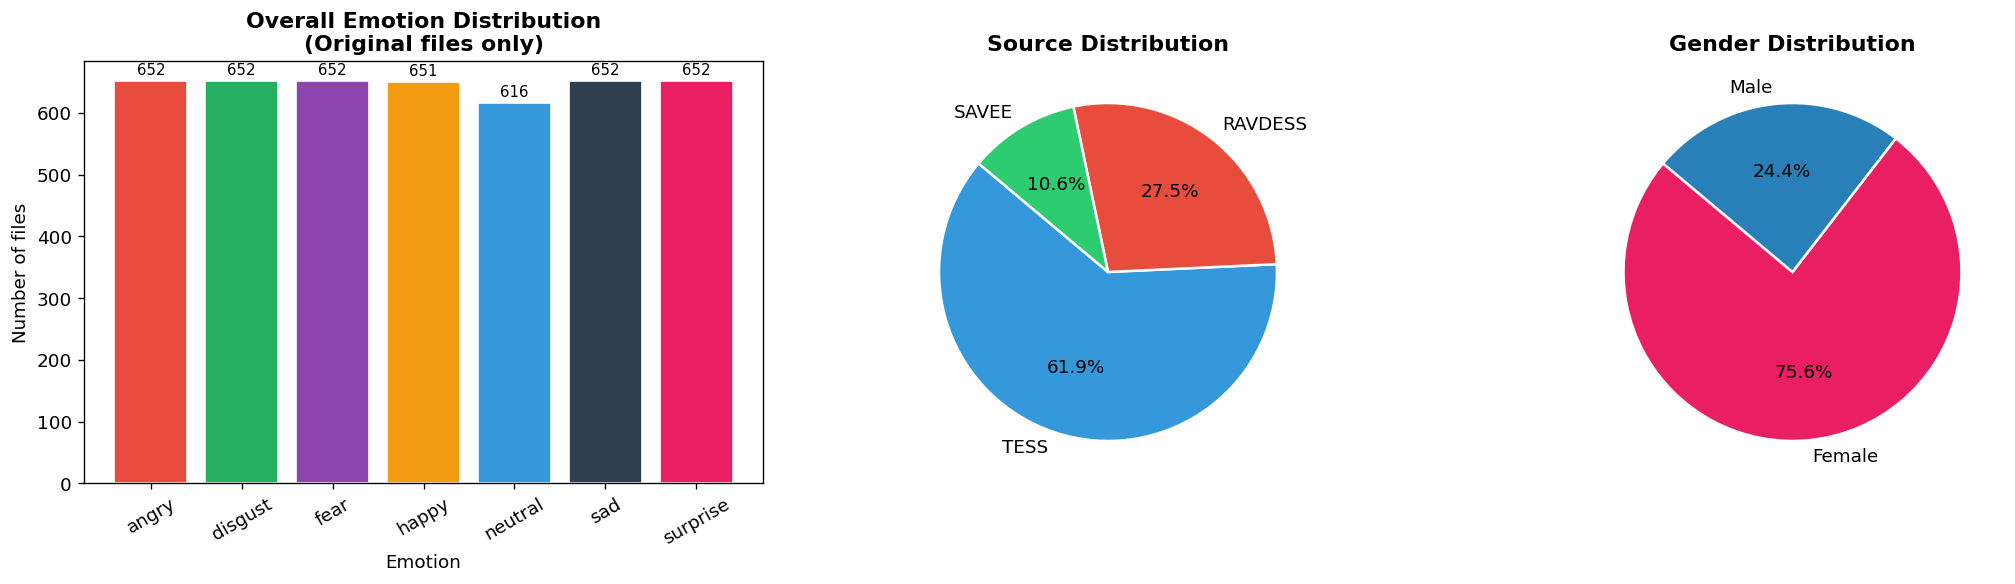

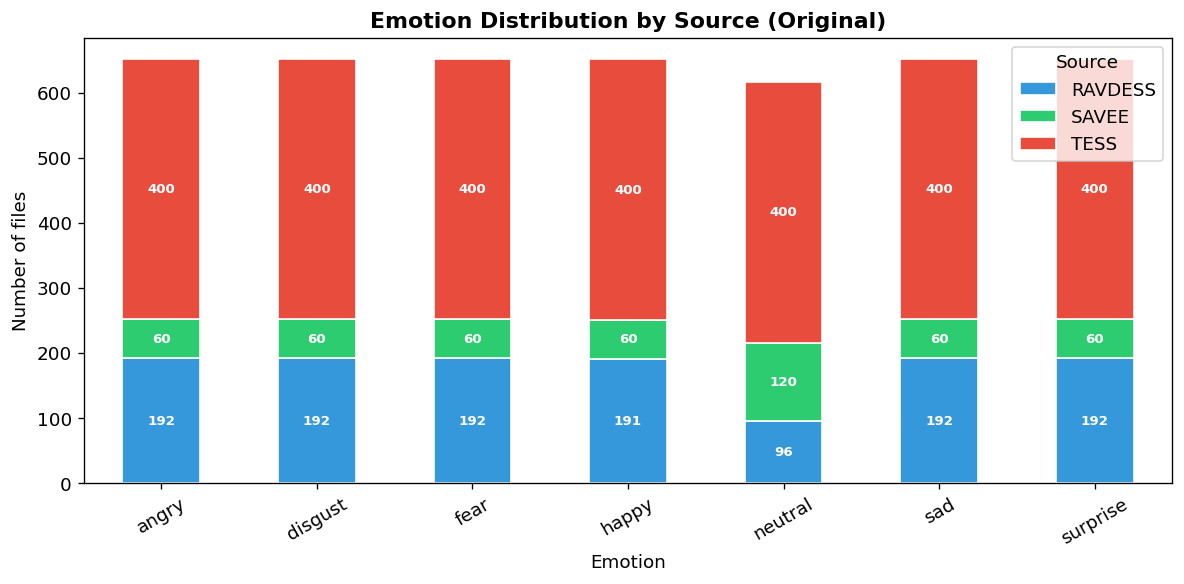

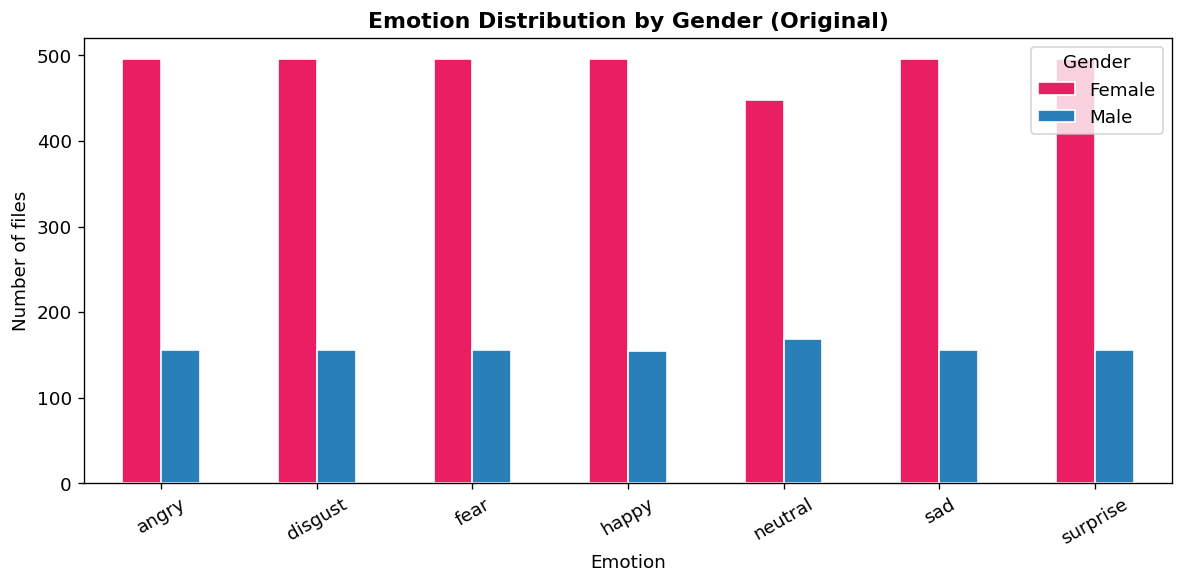

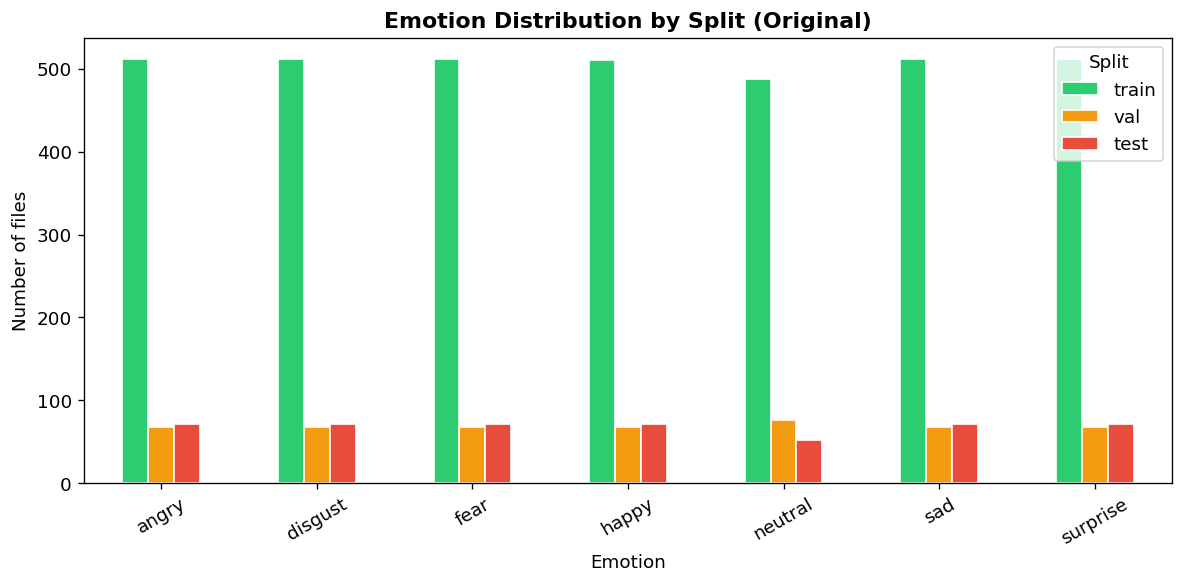

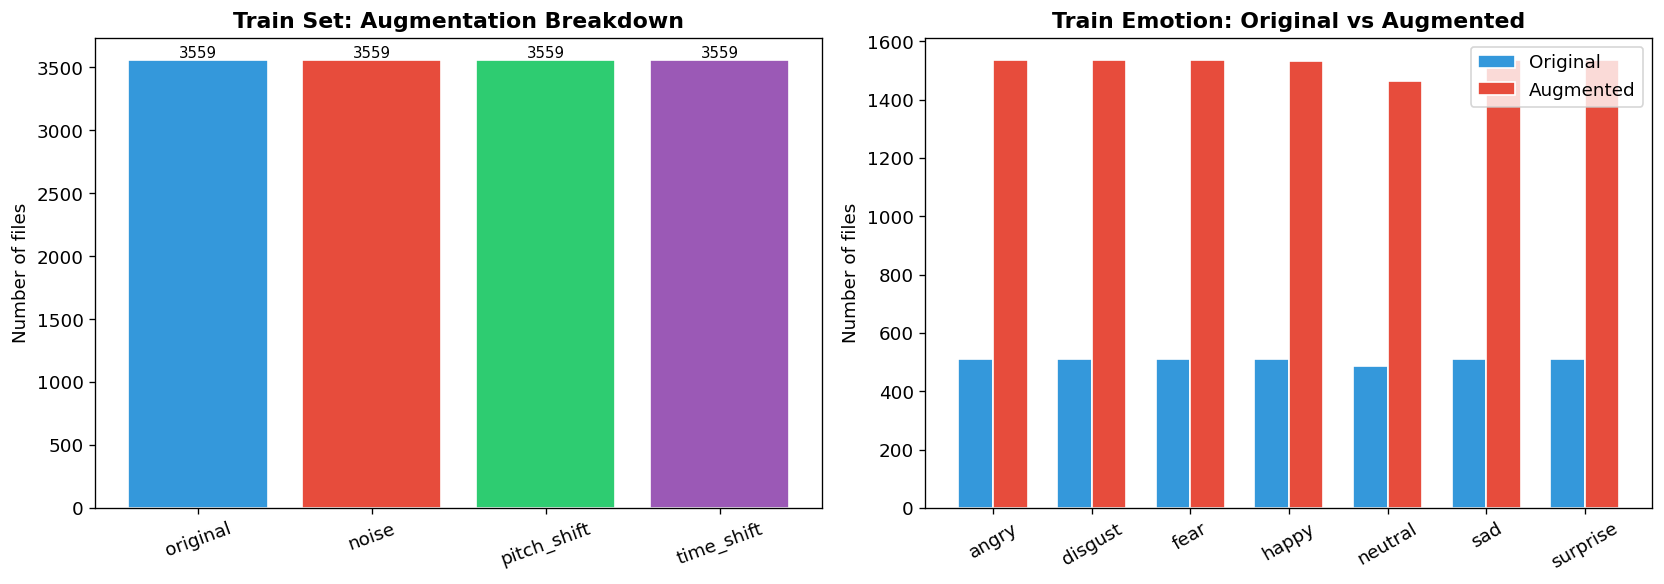

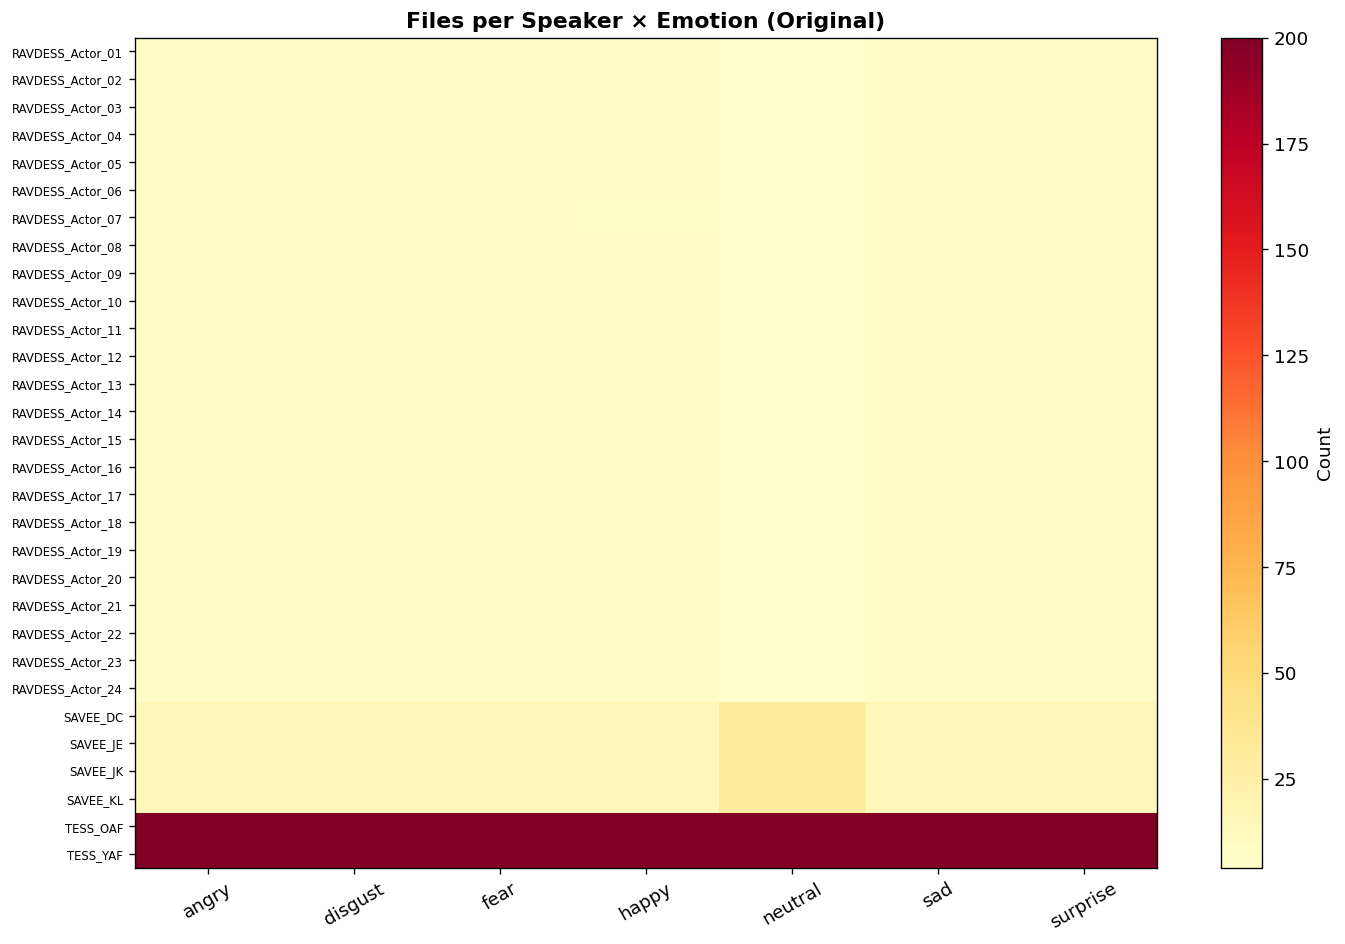

✅ All distribution plots saved to /content/output/
Sample file : 00004_ravdess_RAVDESS_Actor_01_happy.wav
Emotion     : happy
Source      : ravdess
Speaker     : RAVDESS_Actor_01


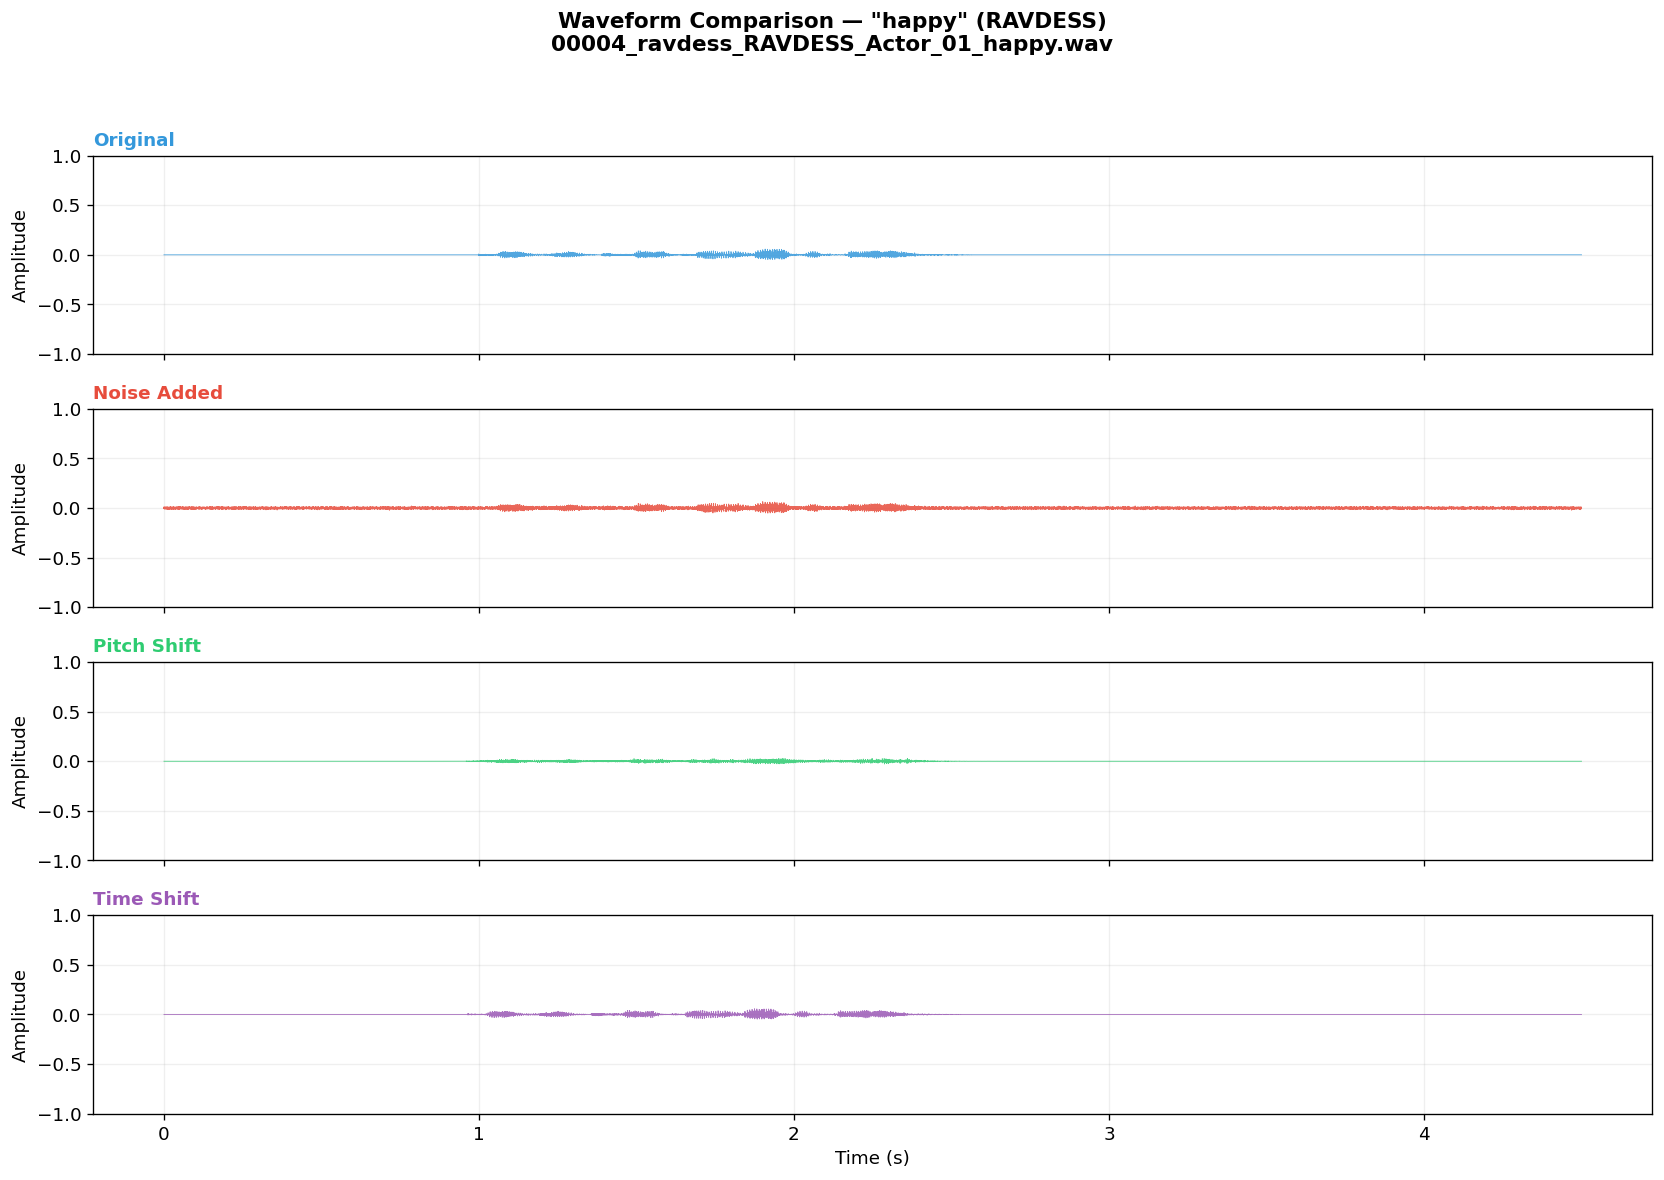

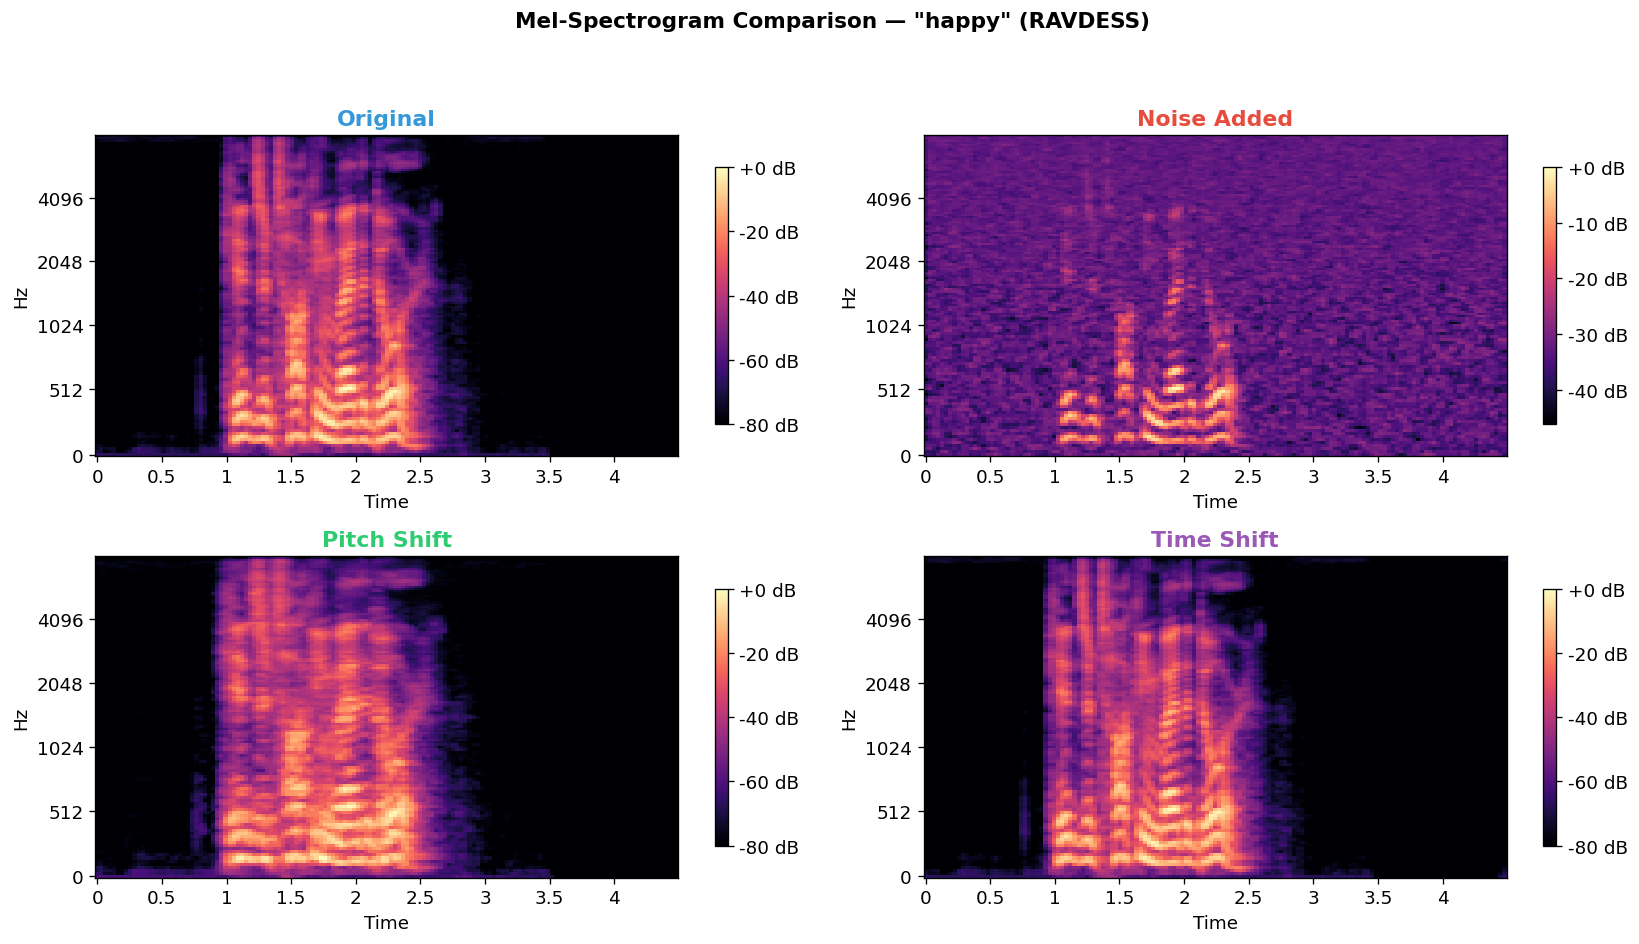

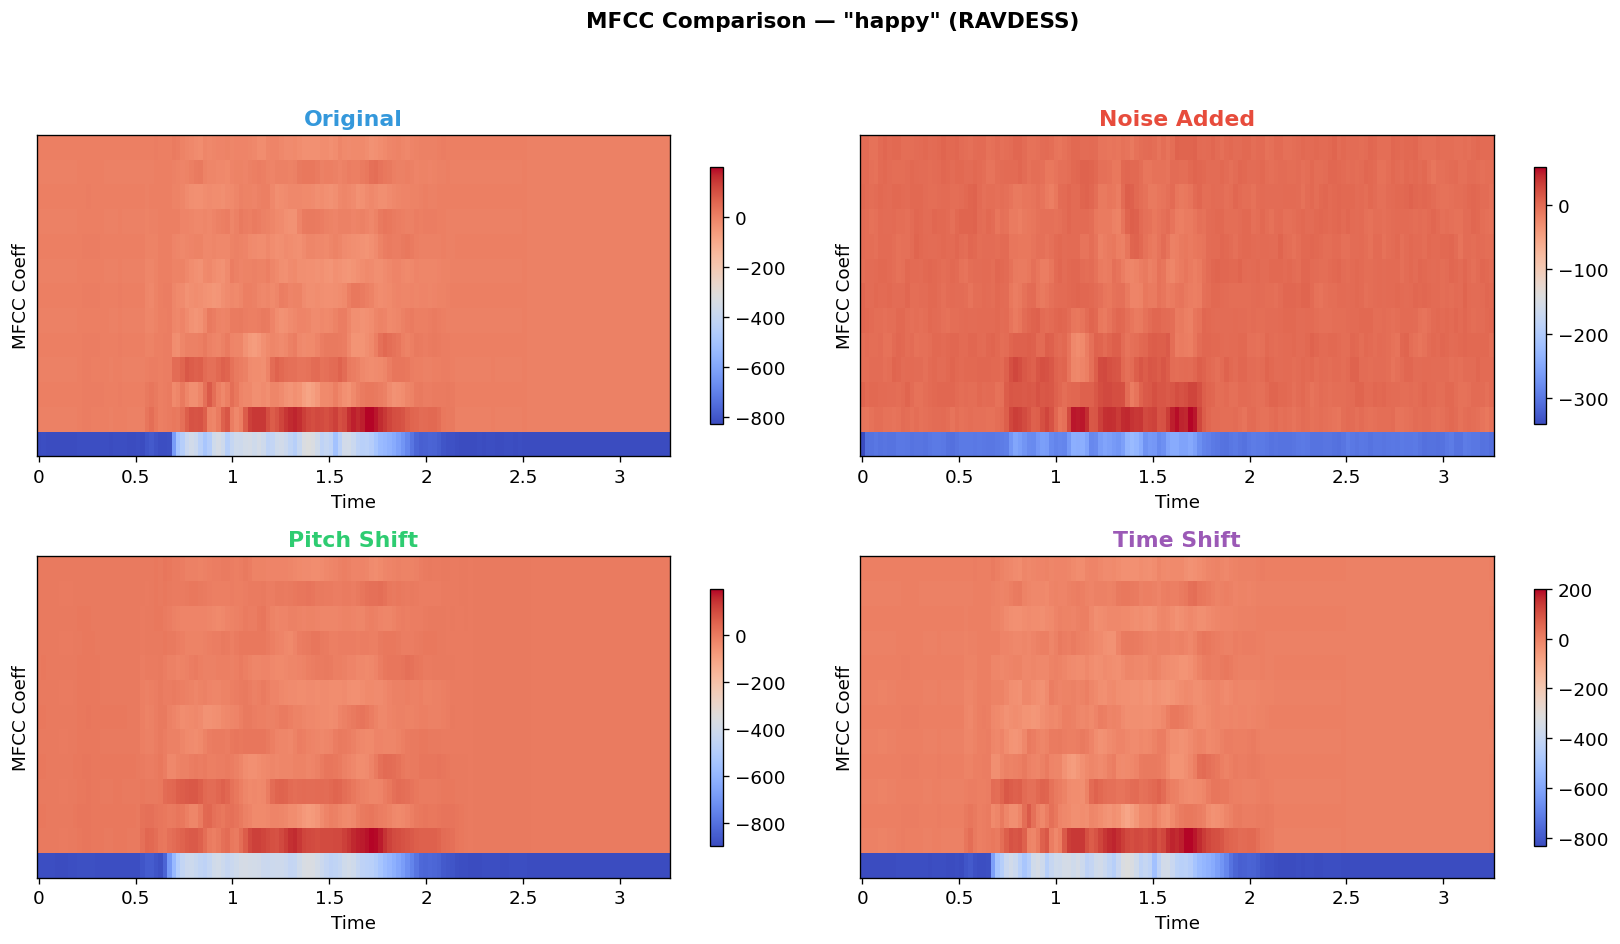

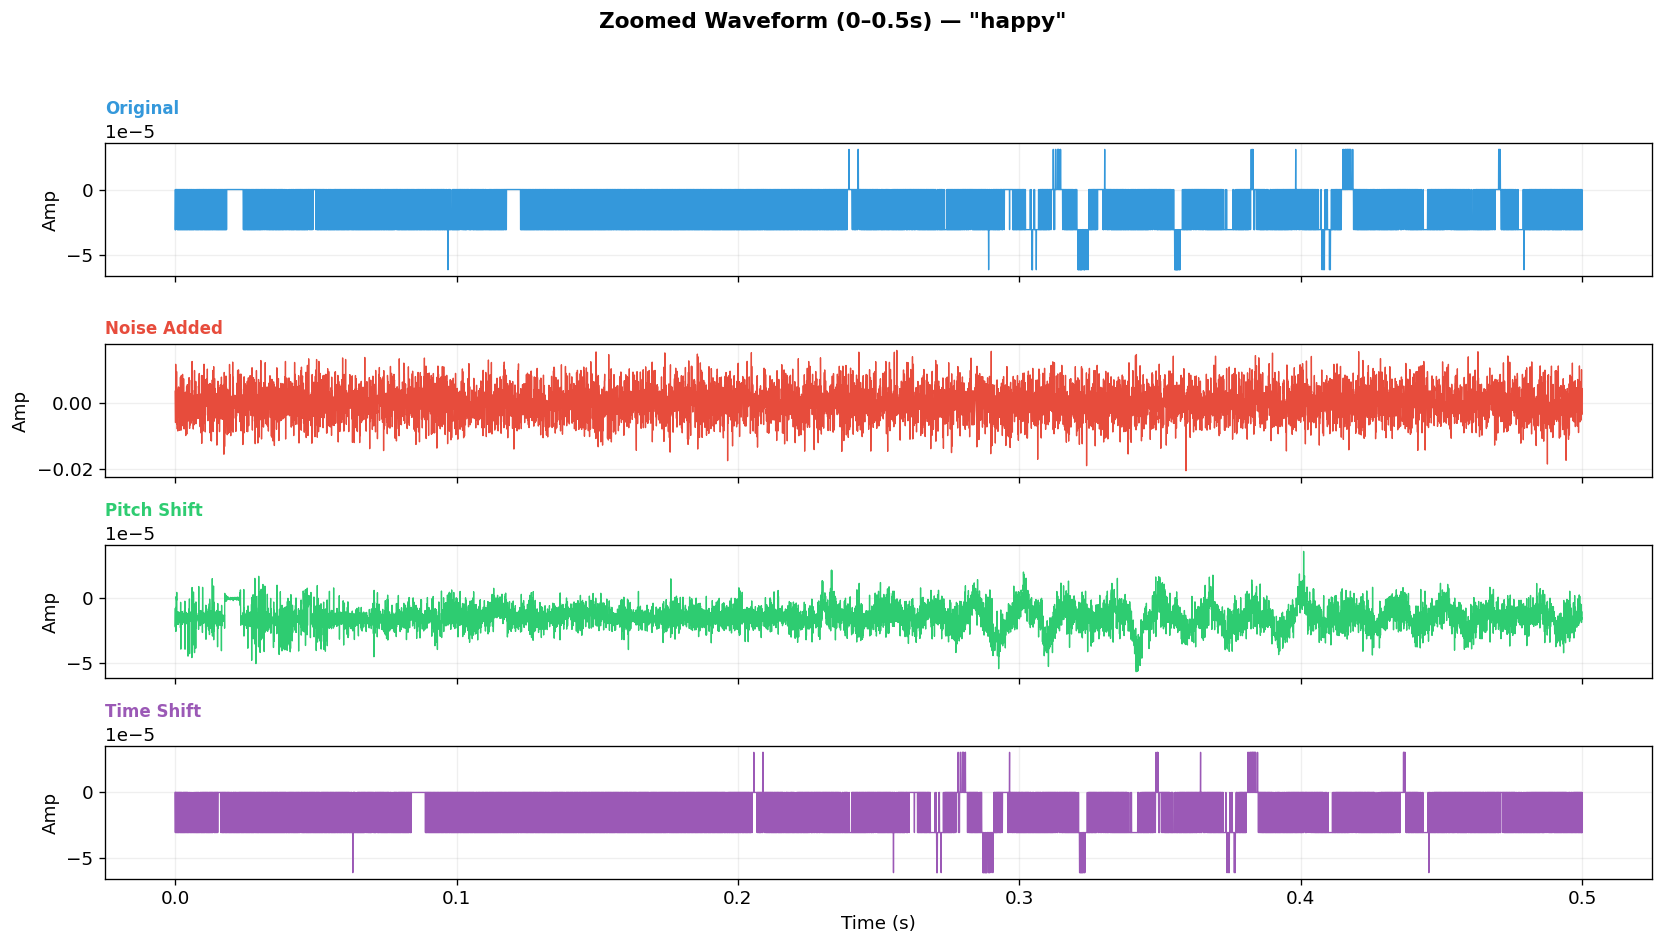

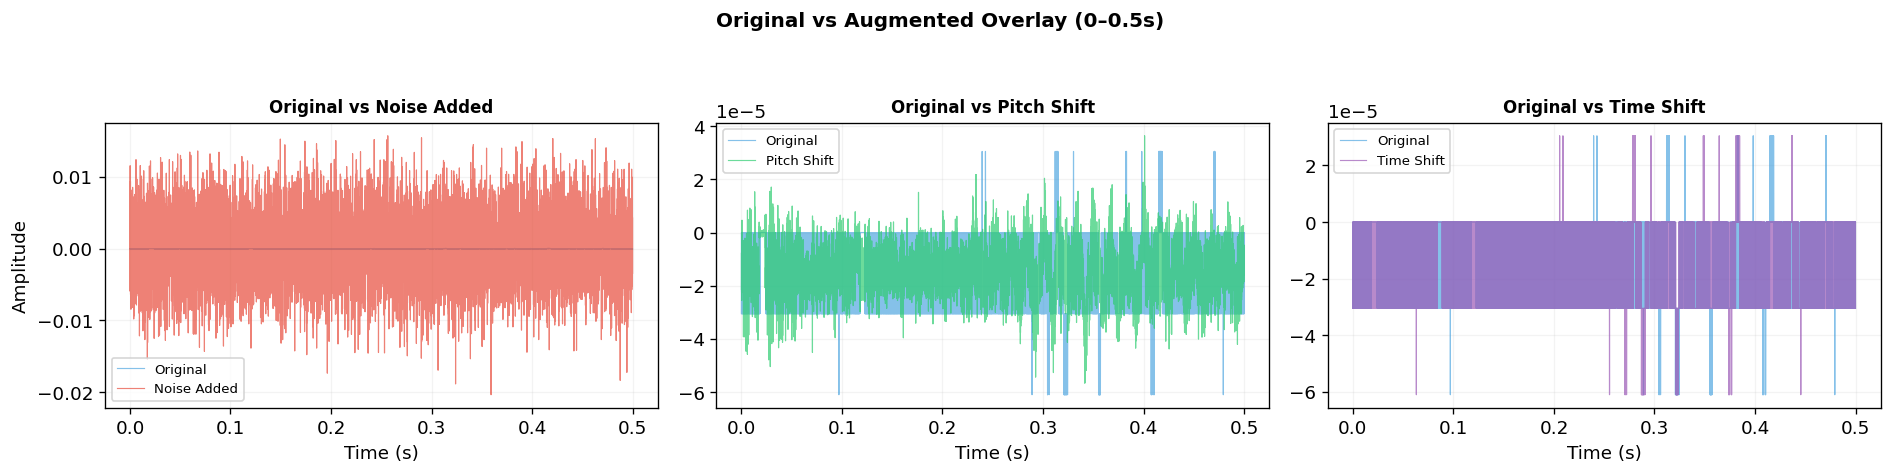


✅ All augmentation visualizations saved to /content/output/
   • plot_overall_distribution.png
   • plot_emotion_by_source.png
   • plot_emotion_by_gender.png
   • plot_emotion_by_split.png
   • plot_train_augmentation.png
   • plot_speaker_emotion_heatmap.png
   • plot_augmentation_waveforms.png
   • plot_augmentation_melspec.png
   • plot_augmentation_mfcc.png
   • plot_augmentation_zoomed.png
   • plot_augmentation_overlay.png


In [ ]:
# ============================================================
# CELL 11B: Data Distribution Visualization
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
import librosa
import librosa.display
import numpy as np
import pandas as pd

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

# Load metadata
df_train_csv = pd.read_csv(os.path.join(OUTPUT_DIR, 'train.csv'))
df_val_csv   = pd.read_csv(os.path.join(OUTPUT_DIR, 'val.csv'))
df_test_csv  = pd.read_csv(os.path.join(OUTPUT_DIR, 'test.csv'))

# Tag splits
df_train_csv['split'] = 'train'
df_val_csv['split']   = 'val'
df_test_csv['split']  = 'test'
df_all = pd.concat([df_train_csv, df_val_csv, df_test_csv], ignore_index=True)

# Only originals (no augmentation) for distribution analysis
df_orig = df_all[df_all['augmentation_type'] == 'original'].copy()

EMOTIONS = sorted(df_orig['emotion'].unique())
EMO_COLORS = {
    'angry': '#e74c3c', 'disgust': '#27ae60', 'fear': '#8e44ad',
    'happy': '#f39c12', 'neutral': '#3498db', 'sad': '#2c3e50',
    'surprise': '#e91e63'
}

print("=" * 60)
print("DATA DISTRIBUTION PLOTS")
print("=" * 60)

# ─────────────────────────────────────────────────────────────
# PLOT 1: Overall emotion distribution (original only)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1a — Total emotion counts
emo_counts = df_orig['emotion'].value_counts().reindex(EMOTIONS)
colors = [EMO_COLORS[e] for e in EMOTIONS]
bars = axes[0].bar(EMOTIONS, emo_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Overall Emotion Distribution\n(Original files only)', fontweight='bold')
axes[0].set_ylabel('Number of files')
axes[0].set_xlabel('Emotion')
for bar, val in zip(bars, emo_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

# 1b — Source distribution
src_counts = df_orig['source'].value_counts()
axes[1].pie(src_counts.values, labels=src_counts.index.str.upper(),
            autopct='%1.1f%%', startangle=140,
            colors=['#3498db', '#e74c3c', '#2ecc71'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Source Distribution', fontweight='bold')

# 1c — Gender distribution
gen_counts = df_orig['gender'].value_counts()
axes[2].pie(gen_counts.values, labels=gen_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=['#e91e63', '#2980b9'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[2].set_title('Gender Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_overall_distribution.png'), bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# PLOT 2: Emotion × Source stacked bar
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ct = pd.crosstab(df_orig['emotion'], df_orig['source']).reindex(EMOTIONS)
ct.plot(kind='bar', stacked=True, ax=ax,
        color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_title('Emotion Distribution by Source (Original)', fontweight='bold')
ax.set_ylabel('Number of files')
ax.set_xlabel('Emotion')
ax.legend(title='Source', labels=[s.upper() for s in ct.columns])
ax.tick_params(axis='x', rotation=30)
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=8, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_emotion_by_source.png'), bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# PLOT 3: Emotion × Gender grouped bar
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ct_gen = pd.crosstab(df_orig['emotion'], df_orig['gender']).reindex(EMOTIONS)
ct_gen.plot(kind='bar', ax=ax, color=['#e91e63', '#2980b9'], edgecolor='white')
ax.set_title('Emotion Distribution by Gender (Original)', fontweight='bold')
ax.set_ylabel('Number of files')
ax.set_xlabel('Emotion')
ax.legend(title='Gender')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_emotion_by_gender.png'), bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# PLOT 4: Train / Val / Test split per emotion
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ct_split = pd.crosstab(df_orig['emotion'], df_orig['split']).reindex(EMOTIONS)[['train','val','test']]
ct_split.plot(kind='bar', ax=ax, color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
ax.set_title('Emotion Distribution by Split (Original)', fontweight='bold')
ax.set_ylabel('Number of files')
ax.set_xlabel('Emotion')
ax.legend(title='Split')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_emotion_by_split.png'), bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# PLOT 5: Train set — original vs augmented
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 5a — Augmentation type counts
aug_counts = df_train_csv['augmentation_type'].value_counts()
axes[0].bar(aug_counts.index, aug_counts.values,
            color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'], edgecolor='white')
axes[0].set_title('Train Set: Augmentation Breakdown', fontweight='bold')
axes[0].set_ylabel('Number of files')
for i, (label, val) in enumerate(zip(aug_counts.index, aug_counts.values)):
    axes[0].text(i, val + 20, str(val), ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=20)

# 5b — Emotion distribution: original vs all augmented (train)
df_train_orig = df_train_csv[df_train_csv['augmentation_type'] == 'original']
df_train_aug  = df_train_csv[df_train_csv['augmentation_type'] != 'original']

orig_emo = df_train_orig['emotion'].value_counts().reindex(EMOTIONS, fill_value=0)
aug_emo  = df_train_aug['emotion'].value_counts().reindex(EMOTIONS, fill_value=0)

x = np.arange(len(EMOTIONS))
w = 0.35
axes[1].bar(x - w/2, orig_emo.values, w, label='Original', color='#3498db', edgecolor='white')
axes[1].bar(x + w/2, aug_emo.values,  w, label='Augmented', color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(EMOTIONS, rotation=30)
axes[1].set_title('Train Emotion: Original vs Augmented', fontweight='bold')
axes[1].set_ylabel('Number of files')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_train_augmentation.png'), bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# PLOT 6: Speakers per emotion heatmap
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
ct_spk = pd.crosstab(df_orig['speaker_id'], df_orig['emotion']).reindex(columns=EMOTIONS)
im = ax.imshow(ct_spk.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(EMOTIONS)))
ax.set_xticklabels(EMOTIONS, rotation=30)
ax.set_yticks(range(len(ct_spk.index)))
ax.set_yticklabels(ct_spk.index, fontsize=7)
ax.set_title('Files per Speaker × Emotion (Original)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_speaker_emotion_heatmap.png'), bbox_inches='tight')
plt.show()

print("✅ All distribution plots saved to /content/output/")


# ============================================================
# CELL 11C: Sample Audio Augmentation Visualization
# ============================================================

# --- Pick one sample from train originals ---
df_train_orig_all = df_final[
    (df_final['split'] == 'train') & (df_final['augmentation_type'] == 'original')
].reset_index(drop=True)

# Choose a sample with a nice emotion (e.g. happy or angry)
preferred = df_train_orig_all[df_train_orig_all['emotion'] == 'happy']
if len(preferred) == 0:
    preferred = df_train_orig_all
sample_row = preferred.iloc[0]
sample_path = sample_row['filepath']
sample_emotion = sample_row['emotion']
sample_source = sample_row['source']

print(f"Sample file : {sample_row['filename']}")
print(f"Emotion     : {sample_emotion}")
print(f"Source      : {sample_source}")
print(f"Speaker     : {sample_row['speaker_id']}")

# Load original
y_orig, sr = librosa.load(sample_path, sr=TARGET_SR)

# Generate augmentations
y_noise = add_noise(y_orig, noise_factor=0.005)
y_pitch = pitch_shift(y_orig, sr)
np.random.seed(42)  # reproducible shift
y_tshift = time_shift(y_orig, shift_max=0.03)

audio_variants = {
    'Original':    y_orig,
    'Noise Added': y_noise,
    'Pitch Shift': y_pitch,
    'Time Shift':  y_tshift,
}

variant_colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

# ─────────────────────────────────────────────────────────────
# PLOT A: Waveforms comparison
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'Waveform Comparison — "{sample_emotion}" ({sample_source.upper()})\n'
             f'{sample_row["filename"]}',
             fontsize=13, fontweight='bold')

time_axis = np.linspace(0, TARGET_DURATION, TARGET_SAMPLES)

for i, (name, y) in enumerate(audio_variants.items()):
    axes[i].plot(time_axis, y, color=variant_colors[i], linewidth=0.5, alpha=0.85)
    axes[i].set_ylabel('Amplitude')
    axes[i].set_title(name, fontsize=11, loc='left', fontweight='bold', color=variant_colors[i])
    axes[i].set_ylim(-1, 1)
    axes[i].grid(alpha=0.2)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_augmentation_waveforms.png'), bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# PLOT B: Mel-Spectrograms comparison
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'Mel-Spectrogram Comparison — "{sample_emotion}" ({sample_source.upper()})',
             fontsize=13, fontweight='bold')

for idx, (name, y) in enumerate(audio_variants.items()):
    ax = axes[idx // 2][idx % 2]
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel',
                                    sr=sr, fmax=8000, ax=ax, cmap='magma')
    ax.set_title(name, fontweight='bold', color=variant_colors[idx])
    fig.colorbar(img, ax=ax, format='%+2.0f dB', shrink=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_augmentation_melspec.png'), bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# PLOT C: MFCCs comparison
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'MFCC Comparison — "{sample_emotion}" ({sample_source.upper()})',
             fontsize=13, fontweight='bold')

for idx, (name, y) in enumerate(audio_variants.items()):
    ax = axes[idx // 2][idx % 2]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    img = librosa.display.specshow(mfcc, x_axis='time', ax=ax, cmap='coolwarm')
    ax.set_title(name, fontweight='bold', color=variant_colors[idx])
    ax.set_ylabel('MFCC Coeff')
    fig.colorbar(img, ax=ax, shrink=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_augmentation_mfcc.png'), bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# PLOT D: Zoomed-in waveform (first 0.5s) to see differences
# ─────────────────────────────────────────────────────────────
zoom_samples = int(0.5 * sr)  # 0.5 seconds
time_zoom = np.linspace(0, 0.5, zoom_samples)

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'Zoomed Waveform (0–0.5s) — "{sample_emotion}"',
             fontsize=13, fontweight='bold')

for i, (name, y) in enumerate(audio_variants.items()):
    axes[i].plot(time_zoom, y[:zoom_samples], color=variant_colors[i], linewidth=0.8)
    axes[i].set_ylabel('Amp')
    axes[i].set_title(name, fontsize=10, loc='left', fontweight='bold', color=variant_colors[i])
    axes[i].grid(alpha=0.2)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_augmentation_zoomed.png'), bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# PLOT E: Overlay original vs each augmentation
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Original vs Augmented Overlay (0–0.5s)', fontsize=12, fontweight='bold')

aug_names = ['Noise Added', 'Pitch Shift', 'Time Shift']
aug_ys    = [y_noise, y_pitch, y_tshift]

for i, (name, y_aug) in enumerate(zip(aug_names, aug_ys)):
    axes[i].plot(time_zoom, y_orig[:zoom_samples], color='#3498db',
                 linewidth=0.7, alpha=0.6, label='Original')
    axes[i].plot(time_zoom, y_aug[:zoom_samples], color=variant_colors[i+1],
                 linewidth=0.7, alpha=0.7, label=name)
    axes[i].set_title(f'Original vs {name}', fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.15)
    axes[i].set_xlabel('Time (s)')

axes[0].set_ylabel('Amplitude')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_augmentation_overlay.png'), bbox_inches='tight')
plt.show()

print("\n✅ All augmentation visualizations saved to /content/output/")
print("   • plot_overall_distribution.png")
print("   • plot_emotion_by_source.png")
print("   • plot_emotion_by_gender.png")
print("   • plot_emotion_by_split.png")
print("   • plot_train_augmentation.png")
print("   • plot_speaker_emotion_heatmap.png")
print("   • plot_augmentation_waveforms.png")
print("   • plot_augmentation_melspec.png")
print("   • plot_augmentation_mfcc.png")
print("   • plot_augmentation_zoomed.png")
print("   • plot_augmentation_overlay.png")

In [ ]:
# # ============================================================
# # CELL 12: Zip and upload to GCS
# # ============================================================
# # Zip the entire output directory
# !cd /content && zip -r /content/emotion_dataset.zip output/

# print("✅ Zipped to /content/emotion_dataset.zip")

# # Upload to Google Cloud Storage
# bucket_name = "dbm-dat-dataset"
# !gsutil cp /content/emotion_dataset.zip gs://{bucket_name}/

# print(f"✅ Uploaded to gs://{bucket_name}/emotion_dataset.zip")